# Step 0. Importing libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

# Step 1. Understand problems and data


In [3]:
df = pd.read_csv("data.csv.csv")

## 1.1. Descriptive statistics of data

In [ ]:
df.tail() #

,ssn,cc_num,first,last,gender,street,city,state,zip,lat,...,customer_avg_amout_1_day,customer_avg_amount_7_day,customer_avg_amount_30_day,merchant_num_trans_1_day,merchant_num_trans_7_day,merchant_num_trans_30_day,merchant_risk_1_day,merchant_risk_7_day,merchant_risk_30_day,merchant_risk_90_day
8580250,541-29-6890,213165736759790,Evan,Hall,M,3257 Justin Way Apt. 505,Lake Worth,FL,33463,26.5955,...,58.17,44.75,63.60,278.79,60394.79,749787.52,0,10,17,43
8580251,481-16-7192,2295468094663316,Emma,Nielsen,F,006 Vincent Wells Apt. 734,Reading,PA,19606,40.3351,...,22.63,68.70,34.44,583.03,62256.81,458776.62,7,10,13,20
8580252,204-59-4139,4980445034440688,Richard,Reyes,M,7342 Anderson Crest Apt. 697,Reseda,CA,91335,34.2007,...,3.53,20.41,31.97,4574.35,35381.57,690950.01,7,11,21,17
8580253,112-67-3962,371234592325803,Vincent,White,M,7116 Lisa Mountain Suite 351,Whitney,TX,76692,31.9713,...,41.38,27.60,20.19,1957.23,44931.45,259878.19,1,12,18,42
8580254,635-97-7047,2401595919457572,Jacob,Evans,M,8339 Brad Knoll Suite 775,East Haven,CT,6512,41.2805,...,23.80,89.68,4.73,3407.84,37277.99,689242.40,2,10,14,27


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8580255 entries, 0 to 8580254
Data columns (total 44 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   ssn                         object 
 1   cc_num                      int64  
 2   first                       object 
 3   last                        object 
 4   gender                      object 
 5   street                      object 
 6   city                        object 
 7   state                       object 
 8   zip                         int64  
 9   lat                         float64
 10  long                        float64
 11  city_pop                    int64  
 12  job                         object 
 13  dob                         object 
 14  acct_num                    int64  
 15  profile                     object 
 16  trans_num                   object 
 17  trans_date                  object 
 18  trans_time                  object 
 19  unix_time            

In [ ]:
df.describe()

,cc_num,zip,lat,long,city_pop,acct_num,unix_time,amt,is_fraud,merch_lat,...,customer_avg_amout_1_day,customer_avg_amount_7_day,customer_avg_amount_30_day,merchant_num_trans_1_day,merchant_num_trans_7_day,merchant_num_trans_30_day,merchant_risk_1_day,merchant_risk_7_day,merchant_risk_30_day,merchant_risk_90_day
count,8.580255e+06,8.580255e+06,8.580255e+06,8.580255e+06,8.580255e+06,8.580255e+06,8.580255e+06,8.580255e+06,8.580255e+06,8.580255e+06,...,8.580255e+06,8.580255e+06,8.580255e+06,8.580255e+06,8.580255e+06,8.580255e+06,8.580255e+06,8.580255e+06,8.580255e+06,8.580255e+06
mean,3.700648e+17,5.157227e+04,3.744883e+01,-9.216084e+01,2.907052e+05,4.956350e+11,1.667116e+09,7.352633e+01,1.104932e-02,3.744868e+01,...,4.550037e+01,4.551067e+01,3.550847e+01,2.549915e+03,5.048988e+04,5.550027e+05,3.499459e+00,9.250919e+00,1.612524e+01,2.962580e+01
std,1.234194e+18,2.976302e+04,5.231915e+00,1.661300e+01,5.600755e+05,2.923834e+11,8.966578e+06,1.722242e+02,1.045334e-01,5.263954e+00,...,2.568704e+01,2.569211e+01,1.991988e+01,1.414724e+03,2.857881e+04,3.146586e+05,2.290905e+00,3.831121e+00,4.791379e+00,1.224634e+01
min,6.040027e+10,1.002000e+03,1.943860e+01,-1.621739e+02,8.900000e+01,2.981017e+08,1.651878e+09,1.000000e+00,0.000000e+00,1.843919e+01,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+02,1.000000e+03,1.000011e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.865393e+13,2.789200e+04,3.382300e+01,-9.868340e+01,1.759700e+04,2.428282e+11,1.659226e+09,9.140000e+00,0.000000e+00,3.372367e+01,...,2.325000e+01,2.325000e+01,1.826000e+01,1.325040e+03,2.574386e+04,2.824759e+05,2.000000e+00,6.000000e+00,1.300000e+01,1.900000e+01
50%,3.507852e+15,4.820700e+04,3.841750e+01,-8.743240e+01,6.076300e+04,4.933850e+11,1.667414e+09,4.473000e+01,0.000000e+00,3.830780e+01,...,4.550000e+01,4.552000e+01,3.551000e+01,2.549910e+03,5.049119e+04,5.551124e+05,3.000000e+00,9.000000e+00,1.700000e+01,3.000000e+01
75%,4.551310e+15,7.825800e+04,4.112220e+01,-8.006100e+01,2.298070e+05,7.504759e+11,1.673791e+09,8.229000e+01,0.000000e+00,4.124582e+01,...,6.774000e+01,6.777000e+01,5.277000e+01,3.775110e+03,7.523231e+04,8.274608e+05,5.000000e+00,1.200000e+01,2.000000e+01,4.000000e+01
max,4.999685e+18,9.983300e+04,6.485440e+01,-6.747220e+01,2.906700e+06,9.999583e+11,1.683500e+09,4.214540e+04,1.000000e+00,6.585070e+01,...,9.000000e+01,9.000000e+01,7.000000e+01,5.000000e+03,9.999999e+04,1.100000e+06,7.000000e+00,1.500000e+01,2.300000e+01,5.000000e+01


In [ ]:
df.shape

(8580255, 44)

In [5]:
df.isnull().sum()

ssn                           0
cc_num                        0
first                         0
last                          0
gender                        0
street                        0
city                          0
state                         0
zip                           0
lat                           0
long                          0
city_pop                      0
job                           0
dob                           0
acct_num                      0
profile                       0
trans_num                     0
trans_date                    0
trans_time                    0
unix_time                     0
category                      0
amt                           0
is_fraud                      0
merchant                      0
merch_lat                     0
merch_long                    0
customer_num_trans_1_day      0
customer_num_trans_7_day      0
customer_num_trans_30_day     0
trans_time_secs               0
trans_time_hrs                0
trans_ti

## 1.2: Visualize data:

1. Fraud transaction rate:

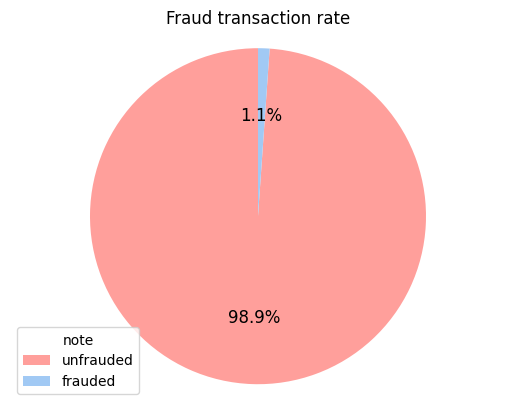

In [ ]:
bi_lua_dao = df['is_fraud'].value_counts()
labels =['unfrauded','frauded']
colors =['#FF9F9B','#A1C9F4']

wedges, texts, autotexts= plt.pie(
    bi_lua_dao,
    autopct='%1.1f%%',
    startangle=90, 
    colors= colors, 
    textprops={'fontsize': 12}
)
plt.title("Fraud transaction rate")

plt.legend(
    wedges,                    
    labels,                   
    title="note",          
    loc="lower left",          
)
plt.axis('equal')  

plt.show()

The chart shows a very large imbalance between normal and fraudulent transactions.

Fraudulent transactions make up only 1.1%, while 98.9% of transactions are legitimate.

This indicates that fraud is a rare occurrence in the dataset and appears only in a very small fraction of all transactions.

2. Fraud rate by amount:

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12524\1117996251.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('amt_bin')['is_fraud']


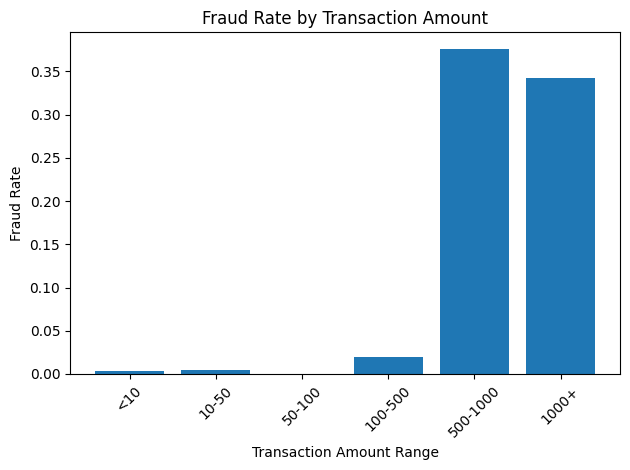

In [10]:
bins = [0, 10, 50, 100, 500, 1000, df['amt'].max()]
labels = ['<10', '10-50', '50-100', '100-500', '500-1000', '1000+']

df['amt_bin'] = pd.cut(df['amt'], bins=bins, labels=labels, include_lowest=True)
fraud_rate = (
    df
    .groupby('amt_bin')['is_fraud']
    .mean()
    .reset_index()
)
plt.figure()
plt.bar(fraud_rate['amt_bin'], fraud_rate['is_fraud'])
plt.xlabel('Transaction Amount Range')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The results indicate a strong positive relationship between transaction amount and fraud incidence. Fraud rates remain negligible for low- and mid-value transactions, but increase substantially for high-value transactions (above 500), suggesting a non-linear risk pattern. This implies that transaction amount is a critical predictive feature for fraud detection and should be weighted more heavily in risk-scoring and monitoring models.

3. Fraud rate by age group:

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12524\339607303.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('age_group')['is_fraud']


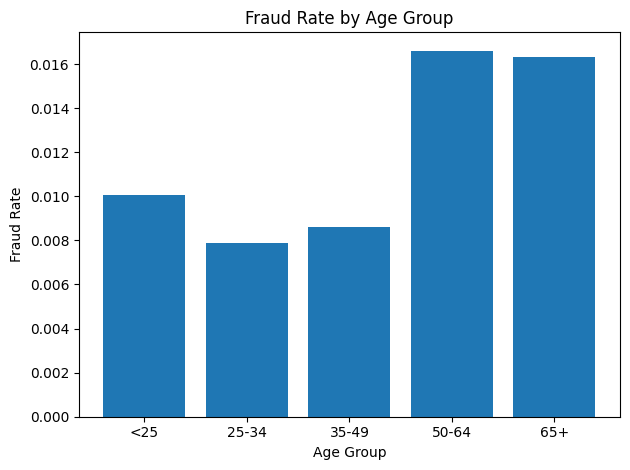

In [11]:
df['dob'] = pd.to_datetime(df['dob'])
df['trans_date'] = pd.to_datetime(df['trans_date'])

df['age'] = (df['trans_date'] - df['dob']).dt.days // 365
age_bins = [0, 25, 35, 50, 65, 100]
age_labels = ['<25', '25-34', '35-49', '50-64', '65+']

df['age_group'] = pd.cut(
    df['age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)
fraud_rate_age = (
    df
    .groupby('age_group')['is_fraud']
    .mean()
    .reset_index()
)
plt.figure()
plt.bar(fraud_rate_age['age_group'], fraud_rate_age['is_fraud'])
plt.xlabel('Age Group')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Age Group')
plt.tight_layout()
plt.show()

The fraud rate exhibits a clear age-related pattern, with lower incidence observed among younger and middle-aged users (25–49) and a marked increase in older age groups (50+). This suggests that age may be a significant demographic factor influencing fraud vulnerability, potentially due to differences in digital literacy, risk awareness, or targeting strategies by fraudsters. Consequently, age should be considered as an important explanatory variable in demographic-based fraud risk modeling and prevention strategies.

4. Fraud cases over time:

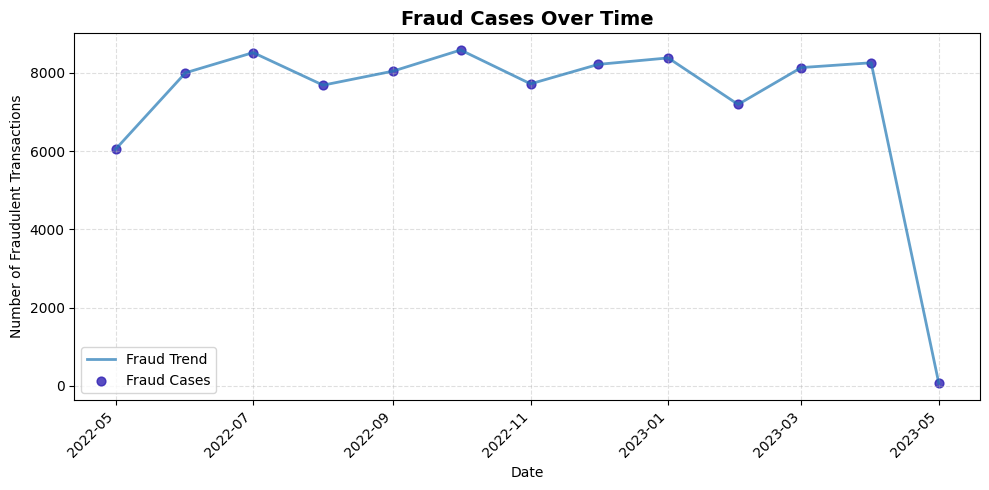

In [4]:
# Đảm bảo cột thời gian đúng định dạng
df['trans_date'] = pd.to_datetime(df['trans_date'])

# Lọc các giao dịch bị fraud
fraud_df = df[df['is_fraud'] == 1]

# Nhóm theo ngày
fraud_trend = fraud_df.groupby(fraud_df['trans_date'].dt.to_period('M')).size()
fraud_trend.index = fraud_trend.index.to_timestamp()

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))

# Line chart thể hiện xu hướng
plt.plot(fraud_trend.index, fraud_trend.values,
         linestyle='-', linewidth=2, alpha=0.7, label='Fraud Trend')

# Scatter plot thể hiện từng điểm cụ thể
plt.scatter(fraud_trend.index, fraud_trend.values,
            color="#2E1FB3C1", s=40, alpha=0.8, label='Fraud Cases')

# Thêm chi tiết
plt.title("Fraud Cases Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Number of Fraudulent Transactions")
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Fraudulent activity remains consistently high across the observed period, with monthly counts clustering tightly between 7,500 and 8,500. This indicates a stable baseline of fraud rather than seasonal or event-driven fluctuations.                 
The gradual rise from mid-2022 to late-2022 suggests an incremental increase in fraudulent behavior, possibly reflecting higher transaction volumes or adaptive fraud strategies.          
Short dips, such as those observed in November and March, appear to be transient deviations rather than substantive improvements, given how quickly the counts revert to baseline levels.                       
Overall, the time-series pattern highlights a persistent and continuous fraud burden, reinforcing the need for sustained, real-time monitoring rather than periodic intervention.

5. Top 10 category with most fraud cases and highest fraud rate:

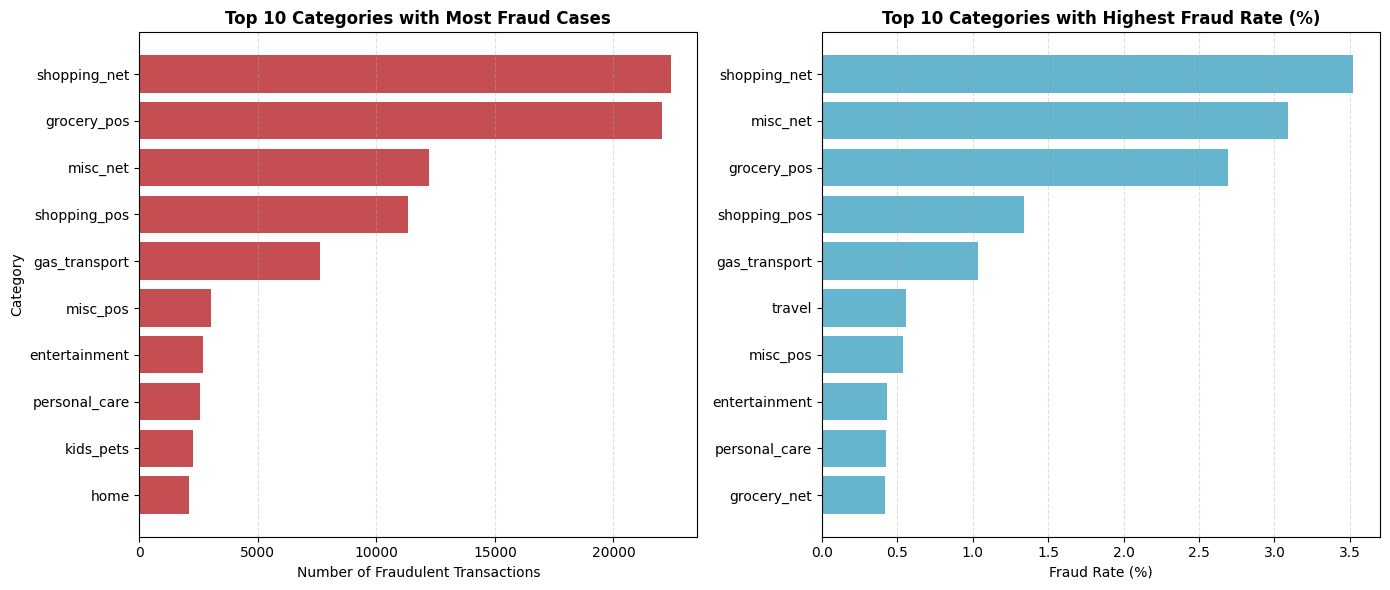

In [ ]:
# Đếm số vụ lừa đảo theo category
fraud_count = df[df['is_fraud'] == 1]['category'].value_counts().head(10)

# Tính tỉ lệ lừa đảo (%) theo category
fraud_rate = (df.groupby('category')['is_fraud'].mean() * 100).sort_values(ascending=False).head(10)

# Tạo figure có 2 subplot cạnh nhau 
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Biểu đồ 1: Top 10 category có số vụ lừa đảo
axes[0].barh(fraud_count.index[::-1], fraud_count.values[::-1], color='#C44E52')
axes[0].set_title('Top 10 Categories with Most Fraud Cases', fontsize=12, weight='bold')
axes[0].set_xlabel('Number of Fraudulent Transactions')
axes[0].set_ylabel('Category')
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

# Biểu đồ 2: Top 10 category có tỉ lệ lừa đảo cao nhất 
axes[1].barh(fraud_rate.index[::-1], fraud_rate.values[::-1], color='#64B5CD')
axes[1].set_title('Top 10 Categories with Highest Fraud Rate (%)', fontsize=12, weight='bold')
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].set_ylabel('')
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

# Căn chỉnh tổng thể 
plt.tight_layout()
plt.show()


The left chart shows that fraud is most frequent in high-volume spending categories such as grocery_pos, shopping_net, and misc_net. These categories naturally accumulate more fraud cases due to their large transaction volumes. However, when normalized by category size (right chart), the highest fraud rates occur in shopping_net, misc_net, and grocery_pos, indicating that online and miscellaneous transactions are disproportionately targeted relative to their overall activity.

The alignment between high case counts and high fraud rates in online-related categories highlights their elevated risk exposure. In contrast, categories such as gas_transport and entertainment appear in both rankings but at lower levels, suggesting moderate but consistent vulnerability. Overall, the results emphasize that online and miscellaneous spending channels represent key hotspots for fraudulent.

6. Fraud Density Heatmap:

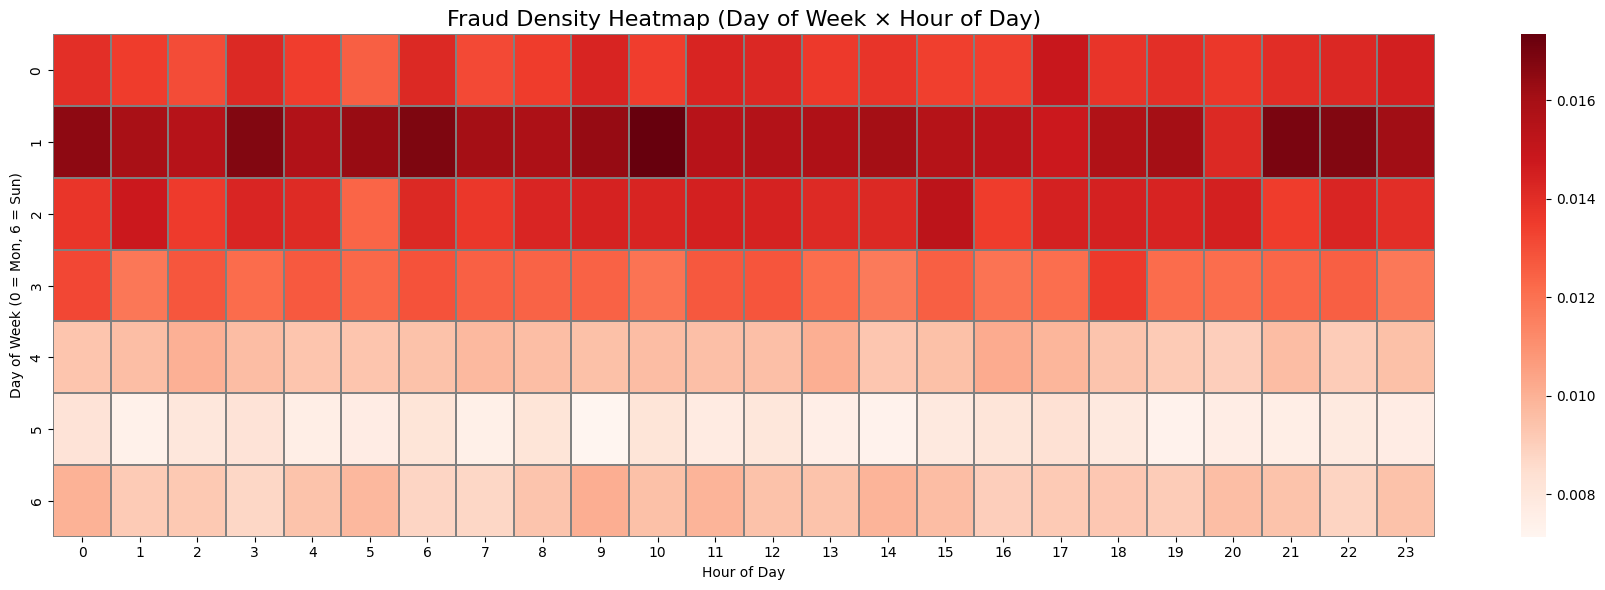

In [ ]:
# Chuyển trans_date thành datetime
df['trans_date'] = pd.to_datetime(df['trans_date'])

# Tạo thêm cột dayofweek (0=Mon, 6=Sun)
df['day_of_week'] = df['trans_date'].dt.dayofweek

# Nhóm theo giờ và ngày, tính tỷ lệ fraud
fraud_heatmap = df.groupby(['day_of_week', 'trans_time_hrs'])['is_fraud'].mean().reset_index()

# Pivot để tạo ma trận cho heatmap
heatmap_matrix = fraud_heatmap.pivot(index='day_of_week', columns='trans_time_hrs', values='is_fraud')

# Vẽ heatmap
plt.figure(figsize=(18, 6))
sns.heatmap(
    heatmap_matrix,
    cmap='Reds',
    linewidths=0.3,
    linecolor='gray'
)

plt.title("Fraud Density Heatmap (Day of Week × Hour of Day)", fontsize=16)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0 = Mon, 6 = Sun)")
plt.tight_layout()
plt.show()

The heatmap reveals clear temporal patterns in fraud density across both day of week and hour of day. Fraud activity is consistently highest during early-morning hours (approximately 01:00–05:00), with Monday and Tuesday showing the most pronounced concentrations. These peaks align with previously observed off-peak hour vulnerabilities, suggesting reduced user vigilance or weaker operational monitoring during nighttime periods.

Mid-week days (Wednesday–Thursday) exhibit moderate fraud intensity, while Friday and Saturday show the lowest levels across almost all hours, indicating reduced fraudulent activity toward the end of the week. Sunday displays a slight increase relative to Friday–Saturday but remains below early-week levels.

Overall, the heatmap highlights a strong weekday effect in combination with early-morning risk windows, underscoring the importance of time-aware detection strategies that adjust sensitivity based on both hour and day-of-week patterns.

7. Fraud rate by Customer Velocity:

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15196\1392451138.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fraud_rate.index, rotation=0)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15196\1392451138.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fraud_rate.index, rotation=0)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15196\1392451138.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fraud_rate.index, rotation=0)


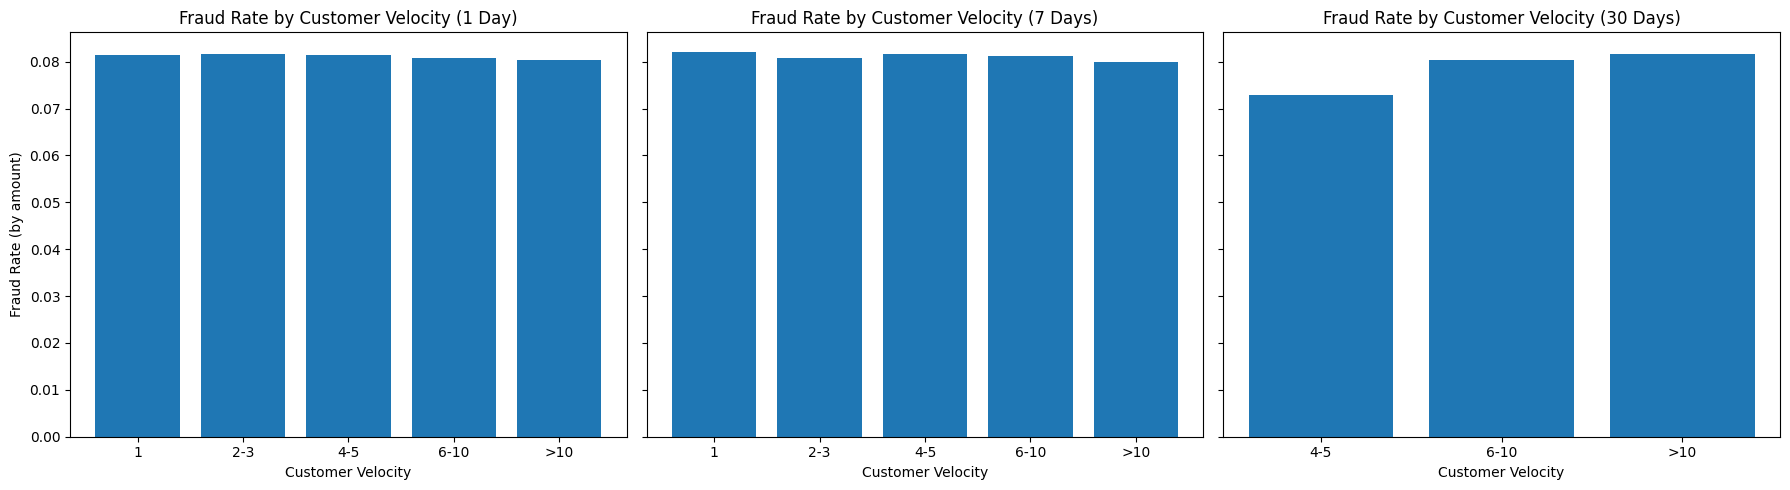

In [5]:
def velocity_bucket(x):
    if x == 1:
        return "1"
    elif 2 <= x <= 3:
        return "2-3"
    elif 4 <= x <= 5:
        return "4-5"
    elif 6 <= x <= 10:
        return "6-10"
    else:
        return ">10"

def fraud_rate_by_amt(df, velocity_col):
    temp = df.copy()
    temp["velocity_bucket"] = temp[velocity_col].apply(velocity_bucket)

    total_amt = temp.groupby("velocity_bucket")["amt"].sum()
    fraud_amt = temp[temp["is_fraud"] == 1].groupby("velocity_bucket")["amt"].sum()

    fraud_rate = (fraud_amt / total_amt).fillna(0)
    return fraud_rate


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

velocity_cols = [
    "customer_num_trans_1_day",
    "customer_num_trans_7_day",
    "customer_num_trans_30_day"
]

titles = [
    "Fraud Rate by Customer Velocity (1 Day)",
    "Fraud Rate by Customer Velocity (7 Days)",
    "Fraud Rate by Customer Velocity (30 Days)"
]

order = ["1", "2-3", "4-5", "6-10", ">10"]

for ax, col, title in zip(axes, velocity_cols, titles):
    fraud_rate = fraud_rate_by_amt(df, col)
    fraud_rate = fraud_rate.reindex(order)

    ax.bar(fraud_rate.index, fraud_rate.values)
    ax.set_title(title)
    ax.set_xlabel("Customer Velocity")
    ax.set_xticklabels(fraud_rate.index, rotation=0)

axes[0].set_ylabel("Fraud Rate (by amount)")

plt.tight_layout()
plt.show()

Across short-term windows (1 and 7 days), fraud rates remain relatively stable across different customer velocity levels, suggesting limited discriminative power of transaction frequency in the short run. However, over a longer horizon (30 days), a clearer positive association emerges, with higher customer velocity corresponding to increased fraud rates. This indicates that sustained high transaction activity, rather than short-term bursts, is more indicative of fraudulent behavior and highlights the importance of incorporating multi-timescale velocity features into fraud detection models.

8. Transaction amount deviation vs Fraud:

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15196\970388052.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15196\970388052.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15196\970388052.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


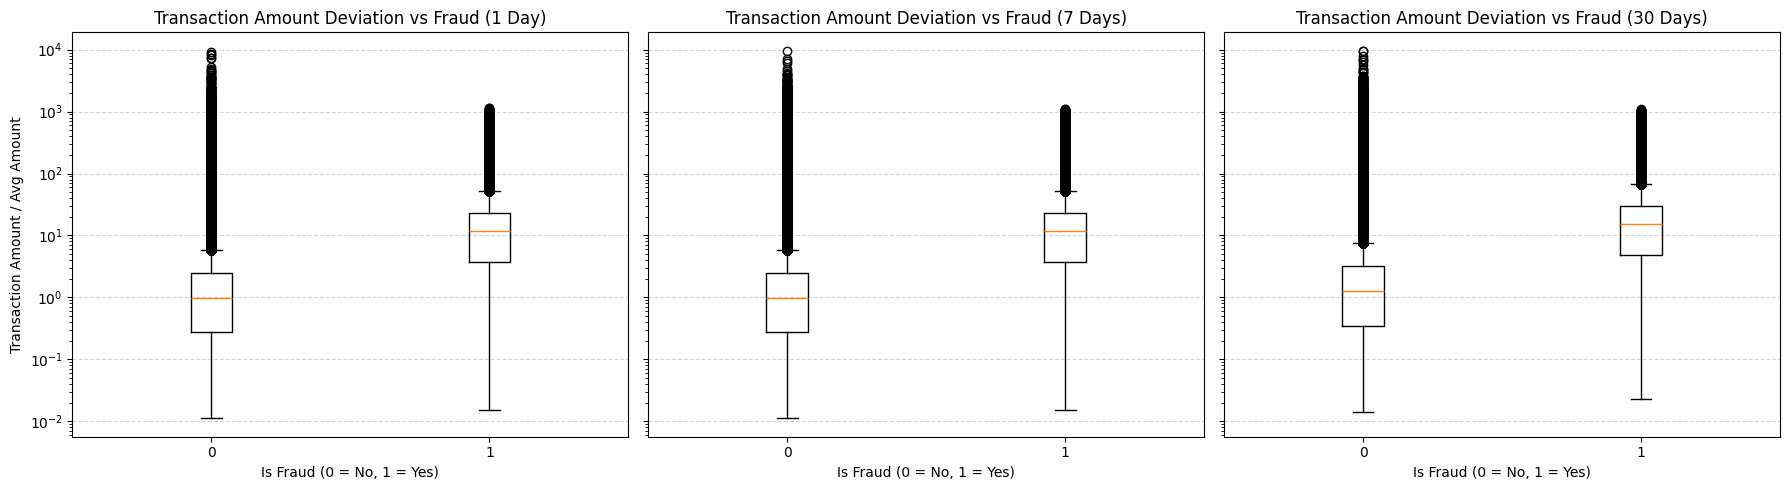

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

windows = [
    ("customer_avg_amout_1_day", "1 Day"),
    ("customer_avg_amount_7_day", "7 Days"),
    ("customer_avg_amount_30_day", "30 Days")
]

for ax, (avg_col, label) in zip(axes, windows):
    temp = df.copy()

    # Tránh chia cho 0
    temp = temp[temp[avg_col] > 0]

    # Deviation
    temp["amt_deviation"] = temp["amt"] / temp[avg_col]

    # Data cho boxplot
    no_fraud = temp[temp["is_fraud"] == 0]["amt_deviation"]
    fraud = temp[temp["is_fraud"] == 1]["amt_deviation"]

    ax.boxplot(
        [no_fraud, fraud],
        labels=["0", "1"],
        showfliers=True
    )

    ax.set_yscale("log")
    ax.set_title(f"Transaction Amount Deviation vs Fraud ({label})")
    ax.set_xlabel("Is Fraud (0 = No, 1 = Yes)")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

axes[0].set_ylabel("Transaction Amount / Avg Amount")

plt.tight_layout()
plt.show()


The boxplots of transaction amount deviation across 1-day, 7-day, and 30-day windows consistently demonstrate a pronounced separation between fraudulent and non-fraudulent transactions. Fraudulent transactions are characterized by substantially higher deviations from customers’ historical average spending, with median transaction-to-average ratios remaining an order of magnitude larger than those observed for legitimate transactions. This pattern is stable across different temporal horizons, indicating that abnormal spending behavior is a persistent characteristic of fraud rather than a short-term anomaly. Overall, these findings reinforce transaction amount deviation as a strong and robust behavioral indicator for fraud detection in this dataset.

## 1.3. Split data into 2 train/test sets:

In [4]:
df['trans_date'] = pd.to_datetime(df['trans_date'])
df['dob'] = pd.to_datetime(df['dob'])

df['age'] = ((df['trans_date'] - df['dob']).dt.days / 365).astype(int)
df['hour'] = df['trans_date'].dt.hour
df['dayofweek'] = df['trans_date'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

In [5]:
# drop leak / id / raw datetime
df = df.drop(columns=[
    'cc_num', 'street', 'zip',
    'merch_lat', 'merch_long',
    'acct_num', 'profile', 'unix_time',
    'trans_num', 'ssn', 'dob',
    'first', 'last', 'trans_date'
], errors='ignore')

In [6]:
# 3. TARGET & COLUMN TYPES
# =========================
target = 'is_fraud'

numeric_features = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numeric_features.remove(target)

X = df.drop(columns=[target])
y = df[target]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [8]:
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (6864204, 43)
Shape of X_test: (1716051, 43)
Shape of y_train: (6864204,)
Shape of y_test: (1716051,)


# Step 2: Data preprocessing:

## 2.1: Create new feature:

Create dob column:

In [5]:
X_train['trans_date'] = pd.to_datetime(X_train['trans_date'], errors='coerce')
X_train['dob'] = pd.to_datetime(X_train['dob'], errors='coerce')

try:
    X_train['trans_time'] = pd.to_timedelta(X_train['trans_time'], errors='coerce')
except Exception:
    X_train['trans_time'] = pd.to_datetime(X_train['trans_time'], errors='coerce')

X_train['trans_date'] = pd.to_datetime(X_train['trans_date'], errors='coerce')
X_train['dob'] = pd.to_datetime(X_train['dob'], errors='coerce')

# Convert trans_time thành timedelta (HH:MM:SS)
X_train['trans_time'] = pd.to_timedelta(X_train['trans_time'], errors='coerce')

# tạo age
X_train['age'] = ((X_train['trans_date'] - X_train['dob']).dt.days / 365).astype(int)

In [6]:
X_test['trans_date'] = pd.to_datetime(X_test['trans_date'], errors='coerce')
X_test['dob'] = pd.to_datetime(X_test['dob'], errors='coerce')

try:
    X_test['trans_time'] = pd.to_timedelta(X_test['trans_time'], errors='coerce')
except Exception:
    X_test['trans_time'] = pd.to_datetime(X_test['trans_time'], errors='coerce')

X_test['trans_date'] = pd.to_datetime(X_test['trans_date'], errors='coerce')
X_test['dob'] = pd.to_datetime(X_test['dob'], errors='coerce')

# Convert trans_time thành timedelta (HH:MM:SS)
X_test['trans_time'] = pd.to_timedelta(X_test['trans_time'], errors='coerce')

# tạo age
X_test['age'] = ((X_test['trans_date'] - X_test['dob']).dt.days / 365).astype(int)

## 2.2. Numerical and categorical:

In [20]:
columns_df = df.columns
columns_df

Index(['ssn', 'cc_num', 'first', 'last', 'gender', 'street', 'city', 'state',
       'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'acct_num', 'profile',
       'trans_num', 'trans_date', 'trans_time', 'unix_time', 'category', 'amt',
       'is_fraud', 'merchant', 'merch_lat', 'merch_long',
       'customer_num_trans_1_day', 'customer_num_trans_7_day',
       'customer_num_trans_30_day', 'trans_time_secs', 'trans_time_hrs',
       'trans_time_is_night', 'trans_time_day', 'trans_date_is_weekend',
       'customer_avg_amout_1_day', 'customer_avg_amount_7_day',
       'customer_avg_amount_30_day', 'merchant_num_trans_1_day',
       'merchant_num_trans_7_day', 'merchant_num_trans_30_day',
       'merchant_risk_1_day', 'merchant_risk_7_day', 'merchant_risk_30_day',
       'merchant_risk_90_day', 'age', 'name'],
      dtype='object')

In [21]:
X.columns

Index(['ssn', 'cc_num', 'first', 'last', 'gender', 'street', 'city', 'state',
       'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'acct_num', 'profile',
       'trans_num', 'trans_date', 'trans_time', 'unix_time', 'category', 'amt',
       'merchant', 'merch_lat', 'merch_long', 'customer_num_trans_1_day',
       'customer_num_trans_7_day', 'customer_num_trans_30_day',
       'trans_time_secs', 'trans_time_hrs', 'trans_time_is_night',
       'trans_time_day', 'trans_date_is_weekend', 'customer_avg_amout_1_day',
       'customer_avg_amount_7_day', 'customer_avg_amount_30_day',
       'merchant_num_trans_1_day', 'merchant_num_trans_7_day',
       'merchant_num_trans_30_day', 'merchant_risk_1_day',
       'merchant_risk_7_day', 'merchant_risk_30_day', 'merchant_risk_90_day',
       'age', 'name'],
      dtype='object')

In [22]:
features_lst = list(X.columns)
features_lst

['ssn',
 'cc_num',
 'first',
 'last',
 'gender',
 'street',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'acct_num',
 'profile',
 'trans_num',
 'trans_date',
 'trans_time',
 'unix_time',
 'category',
 'amt',
 'merchant',
 'merch_lat',
 'merch_long',
 'customer_num_trans_1_day',
 'customer_num_trans_7_day',
 'customer_num_trans_30_day',
 'trans_time_secs',
 'trans_time_hrs',
 'trans_time_is_night',
 'trans_time_day',
 'trans_date_is_weekend',
 'customer_avg_amout_1_day',
 'customer_avg_amount_7_day',
 'customer_avg_amount_30_day',
 'merchant_num_trans_1_day',
 'merchant_num_trans_7_day',
 'merchant_num_trans_30_day',
 'merchant_risk_1_day',
 'merchant_risk_7_day',
 'merchant_risk_30_day',
 'merchant_risk_90_day',
 'age',
 'name']

In [21]:
features_num_lst = X.select_dtypes(include=['int64','float64']).columns.tolist()
features_cat_lst = X.select_dtypes(include=['object']).columns.tolist()

In [24]:
print("Numerical features:", features_num_lst)
print("Categorical features:", features_cat_lst)

Numerical features: ['cc_num', 'zip', 'lat', 'long', 'city_pop', 'acct_num', 'unix_time', 'amt', 'merch_lat', 'merch_long', 'customer_num_trans_1_day', 'customer_num_trans_7_day', 'customer_num_trans_30_day', 'trans_time_secs', 'trans_time_hrs', 'trans_time_is_night', 'trans_time_day', 'trans_date_is_weekend', 'customer_avg_amout_1_day', 'customer_avg_amount_7_day', 'customer_avg_amount_30_day', 'merchant_num_trans_1_day', 'merchant_num_trans_7_day', 'merchant_num_trans_30_day', 'merchant_risk_1_day', 'merchant_risk_7_day', 'merchant_risk_30_day', 'merchant_risk_90_day', 'age']
Categorical features: ['ssn', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'profile', 'trans_num', 'category', 'merchant', 'name']


In [25]:
len(features_num_lst)

29

In [22]:
len(features_cat_lst)

13

### Scalling and Encoding:

In [ ]:
# 5. PREPROCESSING PIPELINE

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        min_frequency=100,      
        sparse_output=True
    ))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features)
])

# Step 3: Predictive Model:

## 3.1. Model Logistic Regression:

In [17]:
lr_model = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.1,   
        random_state=42,
        n_jobs=4
    )),
    ('model', LogisticRegression(
        max_iter=1000,
        n_jobs=4
    ))
])

lr_model.fit(X_train, y_train)

c:\Users\vuquo\anaconda3\Lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lat', 'long', 'city_pop',
                                                   'amt',
                                                   'customer_num_trans_1_day',
                                                   'customer_num_trans_7_day',
                                                   'customer_num_trans_30_day',
                                                   'trans_time_secs',
                                                   'trans_time_hrs',
                                                   'trans_time_is_night',
                                                   'trans_time_day',
                                                   'tr...
                                                   'merchant_risk_90_day']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=100))]),
                                                  ['gender', 'city', 'state',
                                                   'job', 'trans_time',
                                                   'category', 'merchant'])])),
                ('smote',
                 SMOTE(n_jobs=4, random_state=42, sampling_strategy=0.1)),
                ('model', LogisticRegression(max_iter=1000, n_jobs=4))])

## 3.2. Model Catboost:

In [26]:
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function='Logloss',
    eval_metric='AUC',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=100,
    max_ctr_complexity=2,
    border_count=64,
    thread_count=4
)

cat_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)

0:	test: 0.9467132	best: 0.9467132 (0)	total: 3.42s	remaining: 17m 3s
100:	test: 0.9886859	best: 0.9886859 (100)	total: 6m 24s	remaining: 12m 38s
200:	test: 0.9918775	best: 0.9918775 (200)	total: 13m 1s	remaining: 6m 25s
299:	test: 0.9930808	best: 0.9930808 (299)	total: 19m 30s	remaining: 0us

bestTest = 0.9930808255
bestIteration = 299



## 3.3. Model XgBoost:

In [ ]:
xgb_model = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.1, random_state=42, n_jobs=4)),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='aucpr',          
        scale_pos_weight=3,           
        tree_method='hist',
        n_jobs=4,
        random_state=42
    ))
])
xgb_model.fit(X_train, y_train)

In [27]:
# 9. EVALUATION FUNCTION

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluate_sklearn(model, X_test, y_test, threshold=0.3):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > threshold).astype(int)

    return {
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

def evaluate_catboost(model, X_test, y_test, threshold=0.3):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > threshold).astype(int)

    return {
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

In [28]:
# 10. COMPARE MODELS

results = []

results.append(
    ['Logistic Regression', *evaluate_sklearn(lr_model, X_test, y_test).values()]
)

results.append(
    ['XGBoost', *evaluate_sklearn(xgb_model, X_test, y_test).values()]
)

results.append(
    ['CatBoost', *evaluate_catboost(cat_model, X_test, y_test).values()]
)

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Precision', 'Recall', 'F1', 'ROC-AUC']
)

print("\n=== MODEL COMPARISON ===")
print(results_df)


=== MODEL COMPARISON ===
                 Model  Precision    Recall        F1   ROC-AUC
0  Logistic Regression   0.299203  0.639576  0.407685  0.905986
1              XGBoost   0.508413  0.701176  0.589435  0.977672
2             CatBoost   0.136906  0.978166  0.240193  0.993081
